# 03 — Detecção de anomalias nas sessões de recarga

No rateio por kWh, cada sessão vira cobrança para um morador. Uma sessão errada (medidor com defeito, energia impossível para o tempo conectado, carro abandonado dias no ponto compartilhado) gera cobrança injusta ou bloqueia o carregador para os vizinhos. O EV ChargeOps chama `POST /anomaly-score` ao final de cada sessão para sinalizar as suspeitas ao síndico **antes** de fechar o rateio.

**Por que um modelo não supervisionado?** Não existe um histórico de sessões rotuladas como "fraude" ou "erro". O que temos são milhares de sessões normais. O **Isolation Forest** aprende como é uma sessão normal e mede o quão fácil é isolar uma sessão nova das demais: quanto mais fácil isolar, mais estranha ela é. Não é preciso definir de antemão todas as regras de anomalia.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve

from ml.config import (
    ANOMALY_MODEL,
    ANOMALY_VERSION,
    ARTIFACTS_DIR,
    COMMERCIAL,
    PRIVATE,
    RANDOM_SEED,
)
from ml.data.loaders import load_sessions
from ml.features import build_anomaly_features
from ml.models.anomaly import (
    ESTIMATOR_PARAMS,
    NORMALIZED_THRESHOLD,
    THRESHOLD_QUANTILE,
    AnomalyModel,
)
from ml.training.datasets import build_anomaly_dataset
from ml.training.evaluate import anomaly_report, inject_anomalies
from ml.training.train import INJECTED_PER_KIND, long_sessions

pd.set_option("display.precision", 3)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
COLORS = {PRIVATE: "#2a78d6", COMMERCIAL: "#eb6834"}
TYPES = [PRIVATE, COMMERCIAL]

## 1. Dados e variáveis

O treino usa só as **sessões válidas** do notebook 01, ou seja, as que representam uma recarga real. Elas são divididas aleatoriamente em 80% para treino e 20% para teste.

As variáveis vêm dos campos que o backend envia na requisição:

| Variável do modelo | Origem |
|---|---|
| `energy_kwh` | energia medida (`energyKwh`) |
| `duration_hours` | tempo conectado (`durationMinutes` / 60) |
| `idle_hours` | tempo conectado sem carregar (`idleMinutes` / 60) |
| `average_power_kw` | potência média informada (`averagePowerKw`) |
| `charging_power_kw` | energia / tempo efetivamente carregando, derivada |
| `start_hour_sin`, `start_hour_cos` | hora de início (`startHour`) em forma circular, para que 23h fique perto de 0h |

**Um modelo por tipo de ponto.** O notebook 01 mostrou que sessões residenciais e públicas são muito diferentes (11 horas contra 2 horas de duração mediana). Um único modelo marcava como anômala qualquer sessão do tipo minoritário. Por isso treinamos **um Isolation Forest para `PRIVATE` e outro para `COMMERCIAL`**, e cada sessão é avaliada pelo modelo do seu tipo.

O dia da semana (`dayOfWeek`) é aceito pela API, mas não entrou na versão 1: nos testes ele não melhorou a detecção e aumentou os falsos positivos.

In [2]:
sessions = load_sessions()
dataset = build_anomaly_dataset(sessions)
train = dataset[~dataset["is_test"]]
test = dataset[dataset["is_test"]]
pd.DataFrame(
    {
        "train": train.groupby("charge_point_type").size(),
        "test": test.groupby("charge_point_type").size(),
    }
)

,train,test
charge_point_type,,
COMMERCIAL,4929,1244
PRIVATE,27010,6712


## 2. Score e limiar

O Isolation Forest produz um score bruto entre 0 e 1 (quanto maior, mais fácil de isolar). Como cada tipo de ponto tem seu próprio modelo, os scores brutos não são comparáveis entre si. A API devolve um **score normalizado** por tipo:

- **0,0** = percentil 1 dos scores de treino (as sessões mais típicas);
- **0,5** = percentil 98 dos scores de treino, que é o **limiar de anomalia**;
- **1,0** = score bruto máximo (1,0).

Entre esses pontos a escala é linear. Assim, `isAnomaly = score >= 0,5` vale igual para os dois tipos, e o limiar foi escolhido para que **cerca de 2% das sessões normais sejam sinalizadas**. Isso equivale ao parâmetro `contamination = 0,02` do Isolation Forest. Para um síndico, revisar 2 de cada 100 sessões é um volume administrável.

,mediana,p98,sinalizadas
charge_point_type,,,
COMMERCIAL,0.051,0.455,0.015
PRIVATE,0.115,0.504,0.022


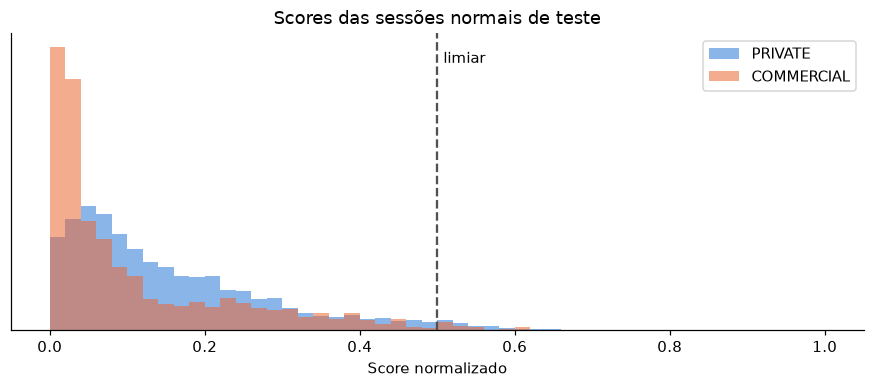

In [3]:
model = AnomalyModel.load(ANOMALY_VERSION)
stored_metrics = json.loads(
    (ARTIFACTS_DIR / ANOMALY_MODEL / ANOMALY_VERSION / "metrics.json").read_text(
        encoding="utf-8"
    )
)
test = test.assign(score=model.score(test))
fig, ax = plt.subplots(figsize=(10, 3.5))
bins = np.linspace(0, 1, 51)
for charge_point_type in TYPES:
    values = test.loc[test["charge_point_type"] == charge_point_type, "score"]
    ax.hist(
        values,
        bins=bins,
        alpha=0.55,
        color=COLORS[charge_point_type],
        label=charge_point_type,
        density=True,
    )
ax.axvline(NORMALIZED_THRESHOLD, color="#52514e", ls="--", lw=1.5)
ax.annotate(
    "limiar",
    (NORMALIZED_THRESHOLD, ax.get_ylim()[1] * 0.9),
    xytext=(4, 0),
    textcoords="offset points",
)
ax.set_xlabel("Score normalizado")
ax.set_yticks([])
ax.set_title("Scores das sessões normais de teste")
ax.legend()
test.groupby("charge_point_type")["score"].agg(
    mediana="median",
    p98=lambda s: s.quantile(0.98),
    sinalizadas=lambda s: (s >= NORMALIZED_THRESHOLD).mean(),
)

## 3. Avaliação com anomalias injetadas

Sem rótulos reais, a forma honesta de medir precisão e cobertura é **injetar anomalias conhecidas** em sessões de teste e verificar se o modelo as encontra. A função `ml.training.evaluate.inject_anomalies` cria 100 casos de cada tipo a partir de sessões reais de teste, com semente fixa:

| Tipo | Como é gerada | O que representa |
|---|---|---|
| `meter_spike` | energia ajustada para potência média 1,5 a 3 vezes acima do limite físico do ponto | medidor com defeito ou registro duplicado |
| `short_burst` | 20 a 60 kWh entregues em 5 a 15 minutos | leitura impossível para um carregador AC |
| `extended_occupation` | conexão estendida para 3 a 5 dias, sem energia adicional | carro abandonado no ponto compartilhado |
| `phantom_occupation` | 12 a 48 horas conectado com menos de 1 kWh | ponto ocupado sem recarregar |

As anomalias somam 400 casos, contra cerca de 8 mil sessões normais de teste (cerca de 5%).

In [4]:
injected = inject_anomalies(test, INJECTED_PER_KIND, np.random.default_rng(RANDOM_SEED))
evaluation = pd.concat(
    [test.assign(anomaly_kind="normal"), injected], ignore_index=True
)
evaluation["score"] = model.score(evaluation)
evaluation["flagged"] = model.is_anomaly(evaluation["score"].to_numpy())
is_injected = evaluation["anomaly_kind"].ne("normal").to_numpy()
overall = {
    "ALL": anomaly_report(is_injected, evaluation["score"].to_numpy(), model.is_anomaly)
}
for charge_point_type in TYPES:
    mask = (evaluation["charge_point_type"] == charge_point_type).to_numpy()
    overall[charge_point_type] = anomaly_report(
        is_injected[mask], evaluation["score"].to_numpy()[mask], model.is_anomaly
    )
print("métricas gravadas em metrics.json:", stored_metrics["test_metrics"])
pd.DataFrame(overall).T

métricas gravadas em metrics.json: {'precision': 0.6570841889117043, 'recall': 0.8, 'f1': 0.7215332581736189, 'false_positive_rate': 0.020990447461035695, 'roc_auc': 0.9687899069884365, 'average_precision': 0.7519561860269292}


,precision,recall,f1,false_positive_rate,roc_auc,average_precision
ALL,0.657,0.800,0.722,0.021,0.969,0.752
PRIVATE,0.635,0.772,0.696,0.022,0.962,0.693
COMMERCIAL,0.768,0.940,0.846,0.015,0.997,0.942


In [5]:
recall = evaluation[is_injected].pivot_table(
    index="anomaly_kind", columns="charge_point_type", values="flagged", aggfunc="mean"
)
recall["ALL"] = evaluation[is_injected].groupby("anomaly_kind")["flagged"].mean()
recall.rename(columns=lambda c: f"cobertura {c}")

charge_point_type,cobertura COMMERCIAL,cobertura PRIVATE,cobertura ALL
anomaly_kind,,,
extended_occupation,1.000,1.000,1.0
meter_spike,1.000,1.000,1.0
phantom_occupation,0.714,0.116,0.2
short_burst,1.000,1.000,1.0


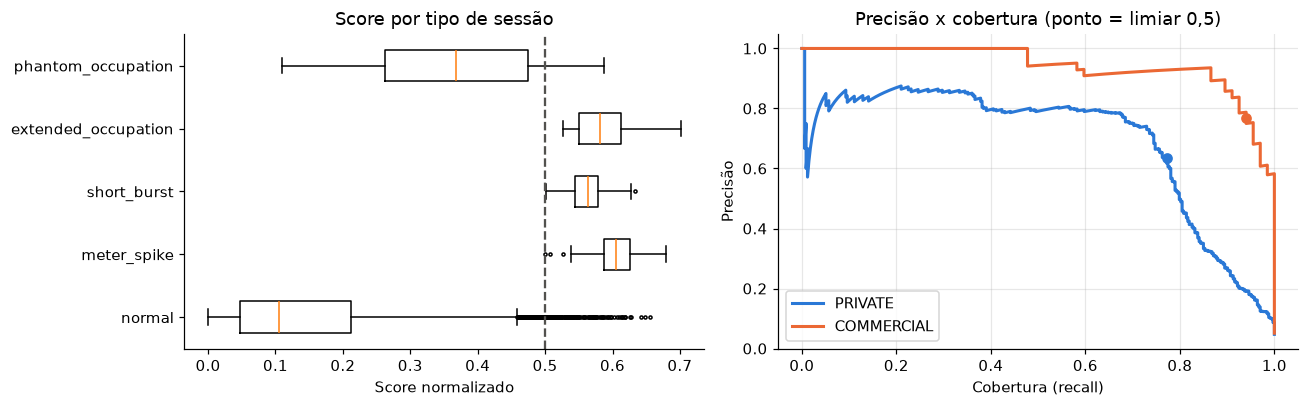

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
kinds = [
    "normal",
    "meter_spike",
    "short_burst",
    "extended_occupation",
    "phantom_occupation",
]
data = [evaluation.loc[evaluation["anomaly_kind"] == kind, "score"] for kind in kinds]
axes[0].boxplot(
    data,
    orientation="horizontal",
    tick_labels=kinds,
    widths=0.5,
    flierprops={"markersize": 2},
)
axes[0].axvline(NORMALIZED_THRESHOLD, color="#52514e", ls="--", lw=1.5)
axes[0].set_xlabel("Score normalizado")
axes[0].set_title("Score por tipo de sessão")
for charge_point_type in TYPES:
    mask = (evaluation["charge_point_type"] == charge_point_type).to_numpy()
    precision, recall_curve, _ = precision_recall_curve(
        is_injected[mask], evaluation["score"][mask]
    )
    axes[1].plot(
        recall_curve,
        precision,
        color=COLORS[charge_point_type],
        lw=2,
        label=charge_point_type,
    )
    row = overall[charge_point_type]
    axes[1].scatter(
        row["recall"], row["precision"], color=COLORS[charge_point_type], zorder=3
    )
axes[1].set_xlabel("Cobertura (recall)")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Precisão x cobertura (ponto = limiar 0,5)")
axes[1].legend()
axes[1].grid(alpha=0.3)
fig.tight_layout()

**Leitura:**

- **Separação geral:** ROC-AUC de 0,97. Escolhendo ao acaso uma sessão anômala e uma normal, em 97% das vezes a anômala tem score maior.
- **No limiar 0,5:** o modelo encontra **80% das anomalias** (cobertura) e **66% das sessões sinalizadas são de fato anômalas** (precisão), sinalizando 2,1% das sessões normais. No uso público os números são melhores (cobertura de 94%, precisão de 77%) porque as sessões normais são mais homogêneas.
- **Por tipo de anomalia:** medidor com defeito (`meter_spike`), energia impossível em poucos minutos (`short_burst`) e carro abandonado por dias (`extended_occupation`) são encontrados em **100% dos casos** nos dois tipos de ponto. São exatamente os erros que distorcem o rateio ou bloqueiam o carregador compartilhado.
- **Ocupação sem recarga (`phantom_occupation`)** é encontrada em 71% dos casos no uso público, mas só em 12% no residencial. **Isso não é uma falha do modelo, é uma característica dos dados:** no notebook 01 vimos que, em casa, é normal conectar o carro à noite e ele quase não carregar porque a bateria já está cheia. O modelo aprendeu que esse comportamento é comum em garagens residenciais. Se o condomínio quiser coibir isso, a ferramenta certa é uma regra de negócio (por exemplo, tarifa por tempo ocioso), e não o detector de anomalias.
- A precisão depende da proporção de anomalias. Aqui injetamos cerca de 5%; se na operação real as anomalias forem mais raras, a fração de alertas falsos entre os sinalizados será maior. Por isso a API devolve o score contínuo, e não só o `isAnomaly`: o backend pode ordenar as sessões por score e mostrar ao síndico as mais suspeitas primeiro.

### Por que um modelo por tipo de ponto?

Para justificar a decisão da seção 1, treinamos um **único** Isolation Forest com as mesmas variáveis e mais uma coluna indicando o tipo de ponto, com o mesmo critério de limiar (percentil 98 do treino), e comparamos com os dois modelos separados.

In [7]:
def with_type(frame):
    is_commercial = (frame["charge_point_type"] == COMMERCIAL).to_numpy(dtype=float)
    return np.column_stack([build_anomaly_features(frame), is_commercial])


single = IsolationForest(**ESTIMATOR_PARAMS).fit(with_type(train))
single_threshold = np.quantile(
    -single.score_samples(with_type(train)), THRESHOLD_QUANTILE
)
single_flagged = -single.score_samples(with_type(evaluation)) >= single_threshold
comparison = {}
for charge_point_type in TYPES:
    mask = (evaluation["charge_point_type"] == charge_point_type).to_numpy()
    for name, flagged in (
        ("modelo único", single_flagged),
        ("um modelo por tipo", evaluation["flagged"].to_numpy()),
    ):
        comparison[(charge_point_type, name)] = {
            "sessões normais sinalizadas": flagged[mask & ~is_injected].mean(),
            "anomalias encontradas": flagged[mask & is_injected].mean(),
        }
pd.DataFrame(comparison).T

sessões normais sinalizadas  \
PRIVATE    modelo único                              0.009   
           um modelo por tipo                        0.022   
COMMERCIAL modelo único                              0.071   
           um modelo por tipo                        0.015   

                               anomalias encontradas  
PRIVATE    modelo único                        0.754  
           um modelo por tipo                  0.772  
COMMERCIAL modelo único                        0.925  
           um modelo por tipo                  0.940

**Leitura:** com um único modelo, as sessões públicas normais são sinalizadas **quase 5 vezes mais** (7,1% contra 1,5%), enquanto as residenciais quase nunca são (0,9%). O modelo único trata o uso público, que é minoritário nos dados, como estranho só por ser diferente do residencial. Com um modelo por tipo, os alertas ficam distribuídos de forma equilibrada (2,2% e 1,5%) e a cobertura das anomalias é um pouco maior nos dois tipos. Para um sistema que gera cobrança, tratar os dois grupos de usuários com o mesmo rigor é um requisito de justiça, e não só de métrica.

### Escolha do limiar

A tabela mostra o que acontece se o limiar for o percentil 95, 98 (o escolhido) ou 99,5 dos scores de treino: quantas sessões normais seriam sinalizadas e quanto das anomalias seria encontrado.

In [8]:
raw = np.zeros(len(evaluation))
train_raw = {}
for charge_point_type in TYPES:
    estimator = model.estimators[charge_point_type]
    train_mask = (train["charge_point_type"] == charge_point_type).to_numpy()
    train_raw[charge_point_type] = -estimator.score_samples(
        build_anomaly_features(train[train_mask])
    )
    mask = (evaluation["charge_point_type"] == charge_point_type).to_numpy()
    raw[mask] = -estimator.score_samples(build_anomaly_features(evaluation[mask]))
rows = {}
for quantile in (0.95, 0.98, 0.995):
    thresholds = evaluation["charge_point_type"].map(
        {name: np.quantile(values, quantile) for name, values in train_raw.items()}
    )
    flagged = raw >= thresholds.to_numpy()
    rows[f"percentil {quantile * 100:g}"] = {
        "sessões normais sinalizadas": flagged[~is_injected].mean(),
        "anomalias encontradas": flagged[is_injected].mean(),
        "precisão": flagged[is_injected].sum() / flagged.sum(),
    }
pd.DataFrame(rows).T

,sessões normais sinalizadas,anomalias encontradas,precisão
percentil 95,0.053,0.850,0.447
percentil 98,0.021,0.800,0.657
percentil 99.5,0.006,0.535,0.817


**Leitura:** o percentil 98 equilibra as duas pontas. Com o percentil 95 o modelo encontra um pouco mais de anomalias (85%), mas mais da metade dos alertas seria falsa (precisão de 45%) e o síndico revisaria 5% de todas as sessões. Com o percentil 99,5 os alertas ficam mais confiáveis (82% de precisão), mas metade das anomalias passaria despercebida. Como cada alerta vira uma revisão manual antes do fechamento do rateio, ficamos com o percentil 98: cerca de 2 revisões a cada 100 sessões e 80% das anomalias encontradas.

## 4. E nas sessões reais que ficaram fora do treino?

O notebook 01 removeu do treino as conexões com mais de 72 horas. Elas não foram injetadas: são sessões reais em que o carro ficou dias no ponto. Se o modelo é útil, deve sinalizá-las sem nunca tê-las visto.

In [9]:
real_long = long_sessions(sessions)
real_long = real_long.assign(score=model.score(real_long))
real_long.groupby("charge_point_type").agg(
    sessions=("session_id", "size"),
    median_duration_hours=("duration_minutes", lambda d: d.median() / 60),
    flagged_share=("score", lambda s: (s >= NORMALIZED_THRESHOLD).mean()),
)

,sessions,median_duration_hours,flagged_share
charge_point_type,,,
COMMERCIAL,28,115.092,1.0
PRIVATE,281,91.350,1.0


### Sessões normais com maior score

Por fim, olhamos as sessões **válidas** do teste com os maiores scores: são os falsos positivos do modelo, ou casos reais estranhos que passaram pelas regras de qualidade.

In [10]:
columns = [
    "site_id",
    "charge_point_type",
    "plugin_time",
    "energy_kwh",
    "duration_minutes",
    "idle_minutes",
    "average_power_kw",
    "score",
]
test.sort_values("score", ascending=False)[columns].head(10)

,site_id,charge_point_type,plugin_time,energy_kwh,duration_minutes,idle_minutes,average_power_kw,score
9854,NO_BOD,PRIVATE,2019-11-09 14:26:00,66.560,4251.000,3887.806,0.939,0.655
25186,NO_TRO,PRIVATE,2019-03-18 18:48:00,88.450,3983.000,3486.294,1.332,0.648
10173,NO_KRO,PRIVATE,2021-03-05 07:51:02,4.255,4281.317,4257.795,0.060,0.643
27162,NO_TRO,PRIVATE,2020-01-27 09:36:00,53.170,3043.000,2744.415,1.048,0.627
20245,NO_OSL_T,PRIVATE,2019-12-28 03:25:00,42.650,3229.000,2973.829,0.793,0.626
37519,TKU_2500,COMMERCIAL,2019-09-03 12:28:00,1.430,3229.000,3205.811,0.027,0.619
38729,TKU_3023,COMMERCIAL,2019-01-18 21:46:00,73.404,254.000,134.966,17.340,0.618
17025,NO_OSL_S,PRIVATE,2019-06-24 00:39:00,69.740,3615.000,2472.707,1.158,0.616
10274,NO_KRO,PRIVATE,2021-03-31 18:06:13,30.420,4119.917,3951.751,0.443,0.615
10124,NO_KRO,PRIVATE,2021-02-19 11:24:21,6.825,4069.633,4031.904,0.101,0.612


**Leitura:**

- **Todas as 309 sessões reais com mais de 72 horas foram sinalizadas** (mediana de 91 horas conectadas no residencial e 115 horas no público). O modelo nunca viu essas sessões no treino e mesmo assim as reconheceu como fora do padrão. É a melhor evidência de que ele funciona fora das anomalias que nós mesmos fabricamos.
- **As sessões normais com maior score** são, em sua maioria, conexões residenciais de 50 a 72 horas, que passaram pela regra de qualidade (até 72 horas) mas já são incomuns, como um fim de semana inteiro no ponto. Aparece também uma sessão pública de 73 kWh em 4 horas, que é energia alta para uma recarga em AC. São casos que um síndico gostaria de ver, então esses "falsos positivos" ainda são úteis para a operação.

## Conclusões

1. **O detector encontra os problemas que mais afetam o rateio e o compartilhamento:** energia impossível para o tempo conectado e carros abandonados por dias são sinalizados em 100% dos casos testados, inclusive nas 309 sessões reais com mais de 72 horas.
2. **O volume de alertas é controlado:** cerca de 2% das sessões normais são sinalizadas, com precisão de 66% e cobertura de 80% no cenário de teste (ROC-AUC de 0,97).
3. **Um modelo por tipo de ponto** distribui os alertas de forma equilibrada. Um modelo único sinalizava sessões públicas normais quase 5 vezes mais que as residenciais.
4. **Integração:** o artefato `artifacts/anomaly/v1/model.joblib` é usado por `POST /anomaly-score`. A resposta traz o score normalizado (0 a 1, limiar 0,5) e `isAnomaly`, e as variáveis são calculadas pela mesma função `ml.features.build_anomaly_features` no treino e na API.
5. **Limitações:**
   - As anomalias de avaliação são sintéticas: medem se o modelo encontra o que sabemos descrever, não anomalias desconhecidas.
   - O tempo ocioso das sessões de treino é estimado.
   - Ocupação sem recarga em garagem residencial é comportamento normal nos dados e não é sinalizada.
   - O dia da semana não é usado na versão 1.
   - Com histórico próprio do condomínio, o síndico pode marcar os alertas como procedentes ou não. Esses rótulos permitem ajustar o limiar e, no futuro, treinar um modelo supervisionado.